# Spike Injection

`spike_injection` adds a handful of localized kernels (Gaussian, triangular, or
rectangular) with random sign, amplitude, width and center. This is the TiRex-2
Stage-1 spike operator: sudden events on top of an otherwise intact series.

| Parameter | Default | Role |
| --- | --- | --- |
| `num_spikes` | 2 | How many kernels are added |
| `amplitude_range` | (1.0, 3.0) | Uniform draw for kernel height |
| `width_range` | (1.0, 5.0) | Uniform draw for kernel width |
| `kernel` | None | Fix the shape, or sample one per spike |
| `rng` / `seed` | `seed=42` | Reproducibility |


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    load_univariate,
    generate_arma_samples,
    generate_nonstationary_sine,
    generate_chirp_signal,
)

L = 512
rng = np.random.RandomState(0)
np.random.seed(0)

synth = np.asarray(generate_arma_samples(L), dtype=float)
real = load_univariate("ETTh1")[:L].astype(float)


def overlay_pair(originals, variants, titles, ylabel="value"):
    # Plot original vs augmented traces for synth (left) and real (right).
    n = len(titles)
    fig, axes = plt.subplots(
        n, 2, figsize=(11.5, 2.55 * n), sharex=False, squeeze=False
    )
    col_titles = ["synthetic (ARMA)", "real (ETTh1 OT)"]
    for col, (orig, var_list) in enumerate(zip(originals, variants)):
        for row, (label, series) in enumerate(var_list):
            ax = axes[row, col]
            ax.plot(orig, color="0.55", lw=1.15, label="original")
            ax.plot(series, color="C0", lw=1.15, alpha=0.9, label=label)
            if row == 0:
                ax.set_title(col_titles[col], fontweight="bold")
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.legend(fontsize=8, loc="upper right", frameon=False)
            ax.grid(True, alpha=0.3)
            axes[row, 0].set_ylabel(titles[row], fontsize=10)
    axes[-1, 0].set_xlabel("t")
    axes[-1, 1].set_xlabel("t")
    fig.tight_layout()
    return fig


def sweep_grid(series_list, names, makers, param_title):
    # makers: list of (label, fn) applied to each series.
    n_s, n_p = len(series_list), len(makers)
    fig, axes = plt.subplots(n_s, n_p, figsize=(3.6 * n_p, 2.5 * n_s), squeeze=False)
    for i, (series, name) in enumerate(zip(series_list, names)):
        for j, (label, fn) in enumerate(makers):
            ax = axes[i, j]
            ax.plot(series, color="0.55", lw=1.0, label="original")
            ax.plot(fn(series), color="C3", lw=1.05, alpha=0.9, label=label)
            if i == 0:
                ax.set_title(label, fontsize=10)
            if j == 0:
                ax.set_ylabel(name)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == n_p - 1:
                ax.legend(fontsize=7, loc="upper right", frameon=False)
    fig.suptitle(param_title, y=1.02, fontweight="bold")
    fig.tight_layout()
    return fig


from s2generator.augmentation import spike_injection

## Default effect on synthetic and real series


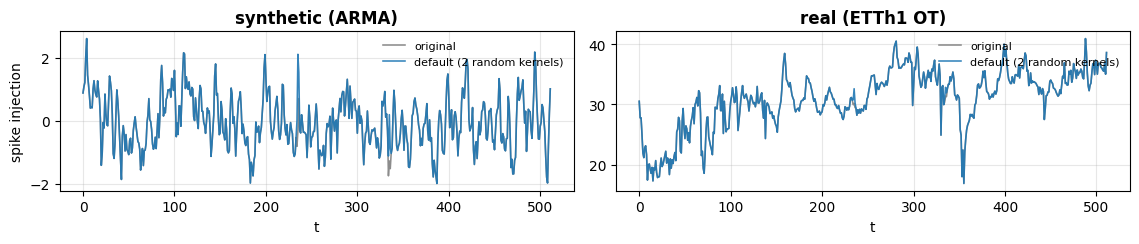

In [2]:
aug_s = spike_injection(synth, rng=np.random.RandomState(1))
aug_r = spike_injection(real, rng=np.random.RandomState(1))
overlay_pair(
    [synth, real],
    [[("default (2 random kernels)", aug_s)], [("default (2 random kernels)", aug_r)]],
    titles=["spike injection"],
)
plt.show()

## Parameter effect

Fix the kernel family, then vary count / amplitude / width. Rectangular spikes
are boxcars; Gaussians leak into the neighbors; large width_range makes bumps
look like local trends.


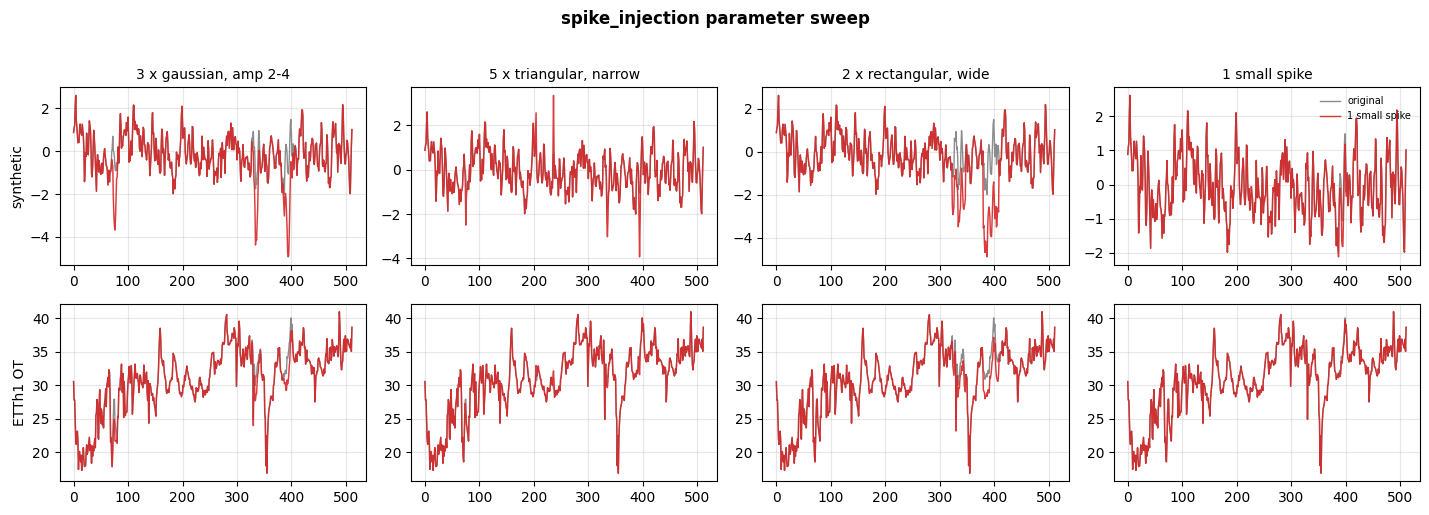

In [3]:
makers = [
    (
        "3 x gaussian, amp 2-4",
        lambda x: spike_injection(
            x,
            num_spikes=3,
            amplitude_range=(2.0, 4.0),
            kernel="gaussian",
            rng=np.random.RandomState(6),
        ),
    ),
    (
        "5 x triangular, narrow",
        lambda x: spike_injection(
            x,
            num_spikes=5,
            width_range=(1.0, 2.0),
            kernel="triangular",
            rng=np.random.RandomState(6),
        ),
    ),
    (
        "2 x rectangular, wide",
        lambda x: spike_injection(
            x,
            num_spikes=2,
            width_range=(8.0, 16.0),
            kernel="rectangular",
            rng=np.random.RandomState(6),
        ),
    ),
    (
        "1 small spike",
        lambda x: spike_injection(
            x,
            num_spikes=1,
            amplitude_range=(0.4, 0.8),
            width_range=(2.0, 4.0),
            kernel="gaussian",
            rng=np.random.RandomState(6),
        ),
    ),
]
sweep_grid(
    [synth, real], ["synthetic", "ETTh1 OT"], makers, "spike_injection parameter sweep"
)
plt.show()